In [ ]:
### ASSIGNMENT- SEABORN ###

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Load dataset
df = pd.read_csv("C:\\Users\\Admin\\Downloads\\U.S.Death.csv")

# Convert date column
df['date'] = pd.to_datetime(df['date'], format='mixed')

# Filter required years
df_1984_2016 = df[(df['year'] >= 1984) & (df['year'] <= 2016)].copy()

print(df_1984_2016.shape)
df_1984_2016.head()

(5698, 10)


,person,dept,eow,cause,cause_short,date,year,canine,dept_name,state
17102,Deputy Sheriff Jerry Bryant,"Marion County Sheriff's Department, MS","EOW: Thursday, January 5, 1984",Cause of Death: Gunfire,Gunfire,1984-01-05,1984,False,Marion County Sheriff's Department,MS
17103,Correctional Officer Dalton B. Cawthray,"Texas Department of Criminal Justice, TX","EOW: Thursday, January 5, 1984",Cause of Death: Gunfire (Accidental),Gunfire (Accidental),1984-01-05,1984,False,Texas Department of Criminal Justice,TX
17104,Parole Officer Michael P. Serano,"Florida Department of Corrections, FL","EOW: Friday, January 6, 1984",Cause of Death: Automobile accident,Automobile accident,1984-01-06,1984,False,Florida Department of Corrections,FL
17105,"Officer Robert C. Reimann, Jr.","Highland Park Police Department, IL","EOW: Friday, January 6, 1984",Cause of Death: Struck by vehicle,Struck by vehicle,1984-01-06,1984,False,Highland Park Police Department,IL
17106,Trooper Robert J. Chab,"Nebraska State Patrol, NE","EOW: Friday, January 6, 1984",Cause of Death: Struck by vehicle,Struck by vehicle,1984-01-06,1984,False,Nebraska State Patrol,NE


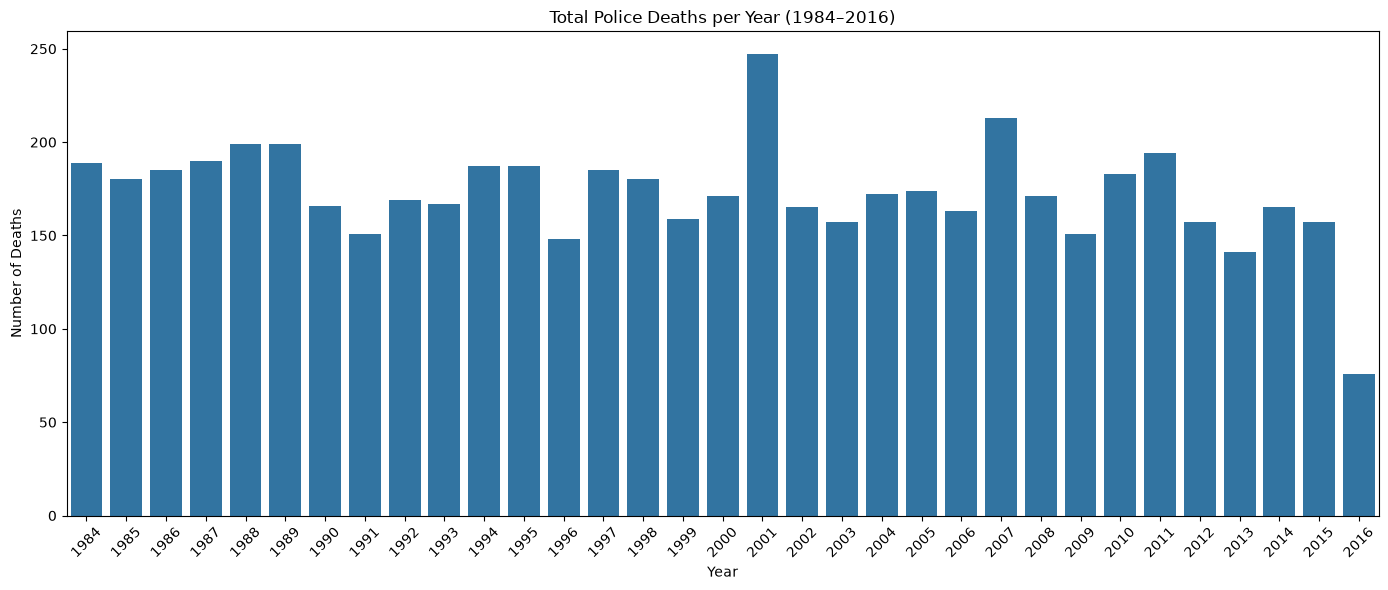

In [4]:
#1. Bar chart showing total deaths per year for 1984–2016

#Answer:
yearly_deaths = df_1984_2016.groupby('year').size().reset_index(name='deaths')

plt.figure(figsize=(14, 6))

sns.barplot(
    data=yearly_deaths,
    x='year',
    y='deaths'
)

plt.title('Total Police Deaths per Year (1984–2016)')
plt.xlabel('Year')
plt.ylabel('Number of Deaths')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

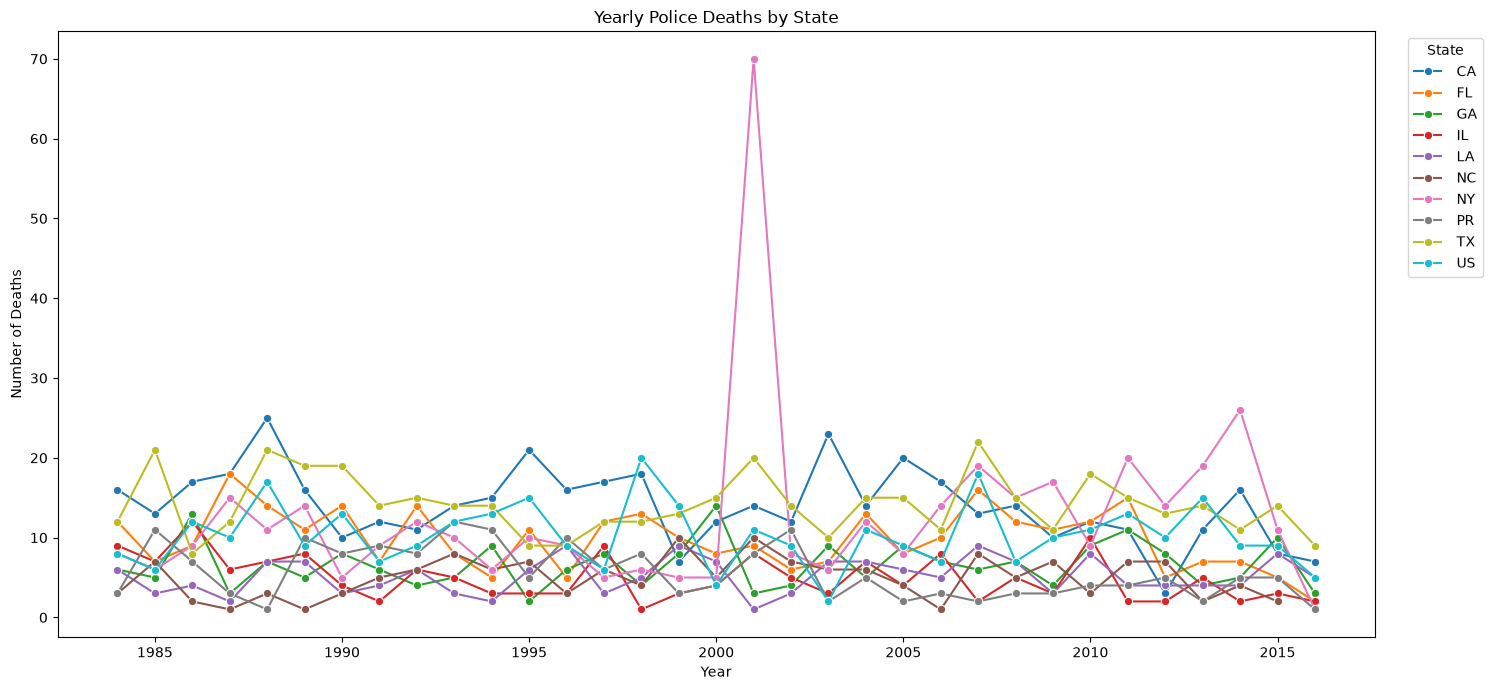

In [5]:
#2. Line chart comparing yearly deaths in different states

#Answer:
top_states = (
    df_1984_2016['state']
    .value_counts()
    .head(10)
    .index
)

state_year = (
    df_1984_2016[df_1984_2016['state'].isin(top_states)]
    .groupby(['year', 'state'])
    .size()
    .reset_index(name='deaths')
)

plt.figure(figsize=(15, 7))

sns.lineplot(
    data=state_year,
    x='year',
    y='deaths',
    hue='state',
    marker='o'
)

plt.title('Yearly Police Deaths by State')
plt.xlabel('Year')
plt.ylabel('Number of Deaths')
plt.legend(title='State', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

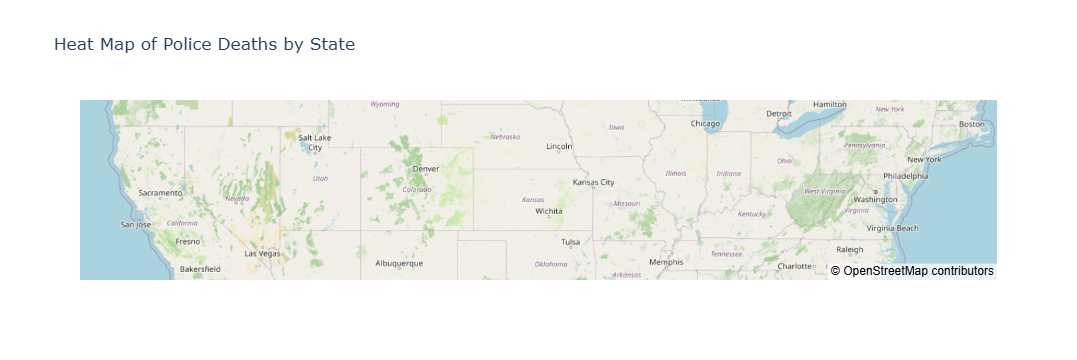

In [7]:
##3. Heat map overlaid on the map of the United States

#There are no latitude/longitude columns in your dataset. Therefore, we can use approximate geographic centers of states to create a state-level heat map.

#Answer:
state_deaths = (
    df_1984_2016.groupby('state')
    .size()
    .reset_index(name='deaths')
)

# Approximate latitude and longitude of state centers
state_coords = {
    'AL': (32.8, -86.8), 'AK': (64.2, -149.5),
    'AZ': (34.0, -111.9), 'AR': (34.8, -92.2),
    'CA': (36.8, -119.4), 'CO': (39.0, -105.5),
    'CT': (41.6, -72.7), 'DE': (39.0, -75.5),
    'FL': (27.8, -81.7), 'GA': (32.7, -83.4),
    'HI': (20.8, -156.3), 'ID': (44.2, -114.5),
    'IL': (40.0, -89.2), 'IN': (40.3, -86.1),
    'IA': (42.0, -93.2), 'KS': (38.5, -98.0),
    'KY': (37.8, -85.3), 'LA': (31.0, -92.0),
    'ME': (45.3, -69.0), 'MD': (39.0, -76.7),
    'MA': (42.4, -71.4), 'MI': (44.3, -85.6),
    'MN': (46.3, -94.3), 'MS': (32.7, -89.7),
    'MO': (38.5, -92.5), 'MT': (47.0, -110.0),
    'NE': (41.5, -99.8), 'NV': (39.3, -116.6),
    'NH': (43.7, -71.6), 'NJ': (40.1, -74.7),
    'NM': (34.5, -106.0), 'NY': (42.9, -75.0),
    'NC': (35.5, -79.4), 'ND': (47.5, -100.5),
    'OH': (40.4, -82.8), 'OK': (35.6, -97.5),
    'OR': (44.0, -120.5), 'PA': (41.2, -77.2),
    'RI': (41.7, -71.5), 'SC': (33.8, -80.9),
    'SD': (44.4, -100.2), 'TN': (35.8, -86.3),
    'TX': (31.0, -99.9), 'UT': (39.3, -111.7),
    'VT': (44.0, -72.7), 'VA': (37.5, -78.7),
    'WA': (47.4, -120.7), 'WV': (38.6, -80.5),
    'WI': (44.5, -89.5), 'WY': (43.0, -107.6)
}

state_deaths['lat'] = state_deaths['state'].map(
    lambda x: state_coords.get(x, (np.nan, np.nan))[0]
)

state_deaths['lon'] = state_deaths['state'].map(
    lambda x: state_coords.get(x, (np.nan, np.nan))[1]
)

fig = px.density_map(
    state_deaths.dropna(),
    lat='lat',
    lon='lon',
    z='deaths',
    radius=30,
    center={'lat': 39, 'lon': -98},
    zoom=3.5,
    map_style='open-street-map',
    title='Heat Map of Police Deaths by State'
)

fig.show()

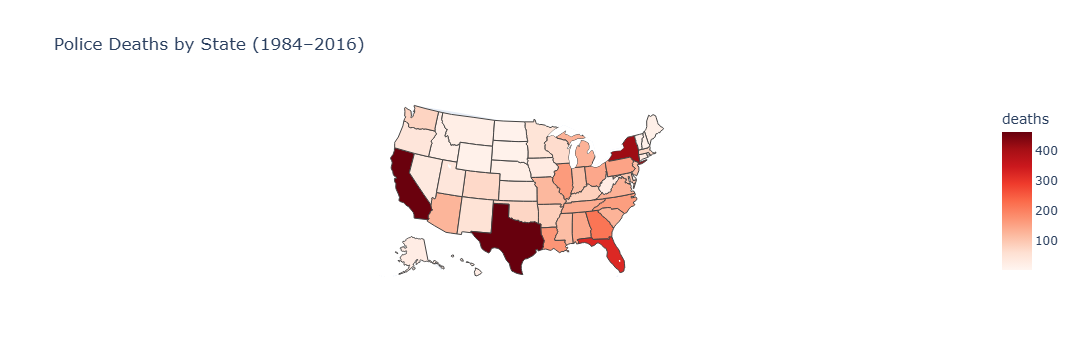

In [8]:
#4. Choropleth comparing police deaths in different states

#Answer:
state_deaths = (
    df_1984_2016.groupby('state')
    .size()
    .reset_index(name='deaths')
)

fig = px.choropleth(
    state_deaths,
    locations='state',
    locationmode='USA-states',
    color='deaths',
    scope='usa',
    color_continuous_scale='Reds',
    title='Police Deaths by State (1984–2016)'
)

fig.show()


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


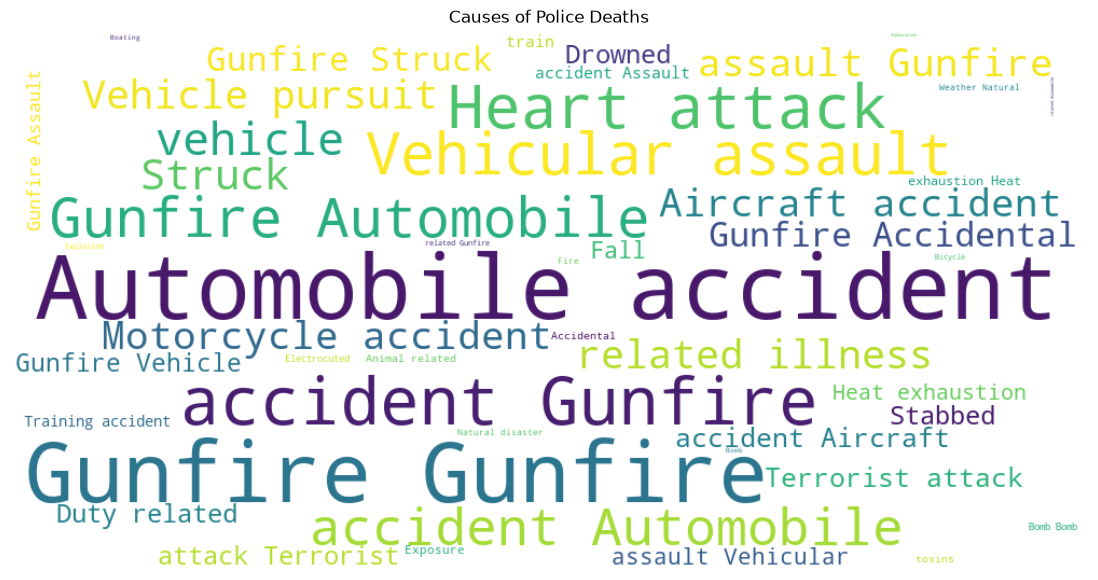

In [9]:
#5. Word cloud of different causes of death

#Answer:
!pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Remove "Cause of Death:"
causes = (
    df_1984_2016['cause']
    .astype(str)
    .str.replace('Cause of Death:', '', regex=False)
)

text = ' '.join(causes)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Causes of Police Deaths')
plt.show()

In [11]:
#6. Marker cluster showing shootings in California

#ANSWER:
!pip install folium
import folium
from folium.plugins import MarkerCluster

# California shootings
ca_shootings = df_1984_2016[
    (df_1984_2016['state'] == 'CA') &
    (df_1984_2016['cause_short'].str.contains('Gunfire|Shooting', case=False, na=False))
].copy()

# California approximate center
m = folium.Map(
    location=[36.7783, -119.4179],
    zoom_start=6
)

marker_cluster = MarkerCluster().add_to(m)

for _, row in ca_shootings.iterrows():

    popup_text = f"""
    <b>Name:</b> {row['person']}<br>
    <b>Cause:</b> {row['cause_short']}<br>
    <b>Date:</b> {row['date'].date()}
    """

    folium.Marker(
        location=[36.7783, -119.4179],
        popup=popup_text,
        tooltip=row['person']
    ).add_to(marker_cluster)

m


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


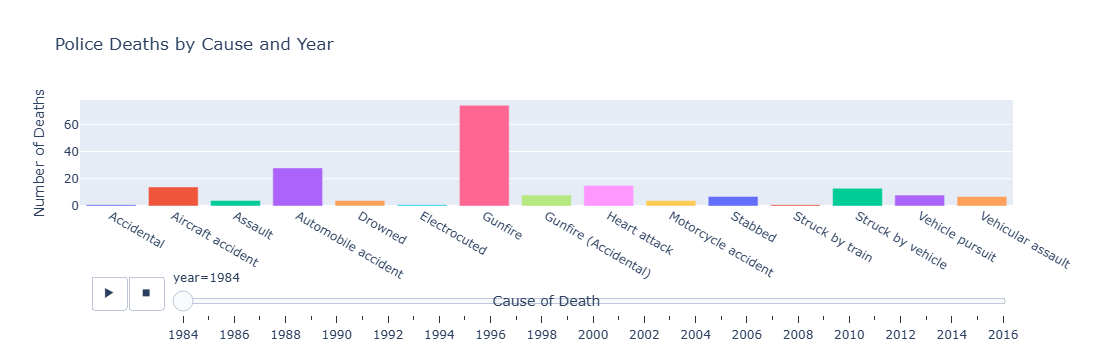

In [12]:
#7. Bar chart comparing deaths due to different causes, animated by year

#Answer:
cause_year = (
    df_1984_2016
    .groupby(['year', 'cause_short'])
    .size()
    .reset_index(name='deaths')
)

fig = px.bar(
    cause_year,
    x='cause_short',
    y='deaths',
    color='cause_short',
    animation_frame='year',
    title='Police Deaths by Cause and Year'
)

fig.update_layout(
    xaxis_title='Cause of Death',
    yaxis_title='Number of Deaths',
    showlegend=False
)

fig.show()

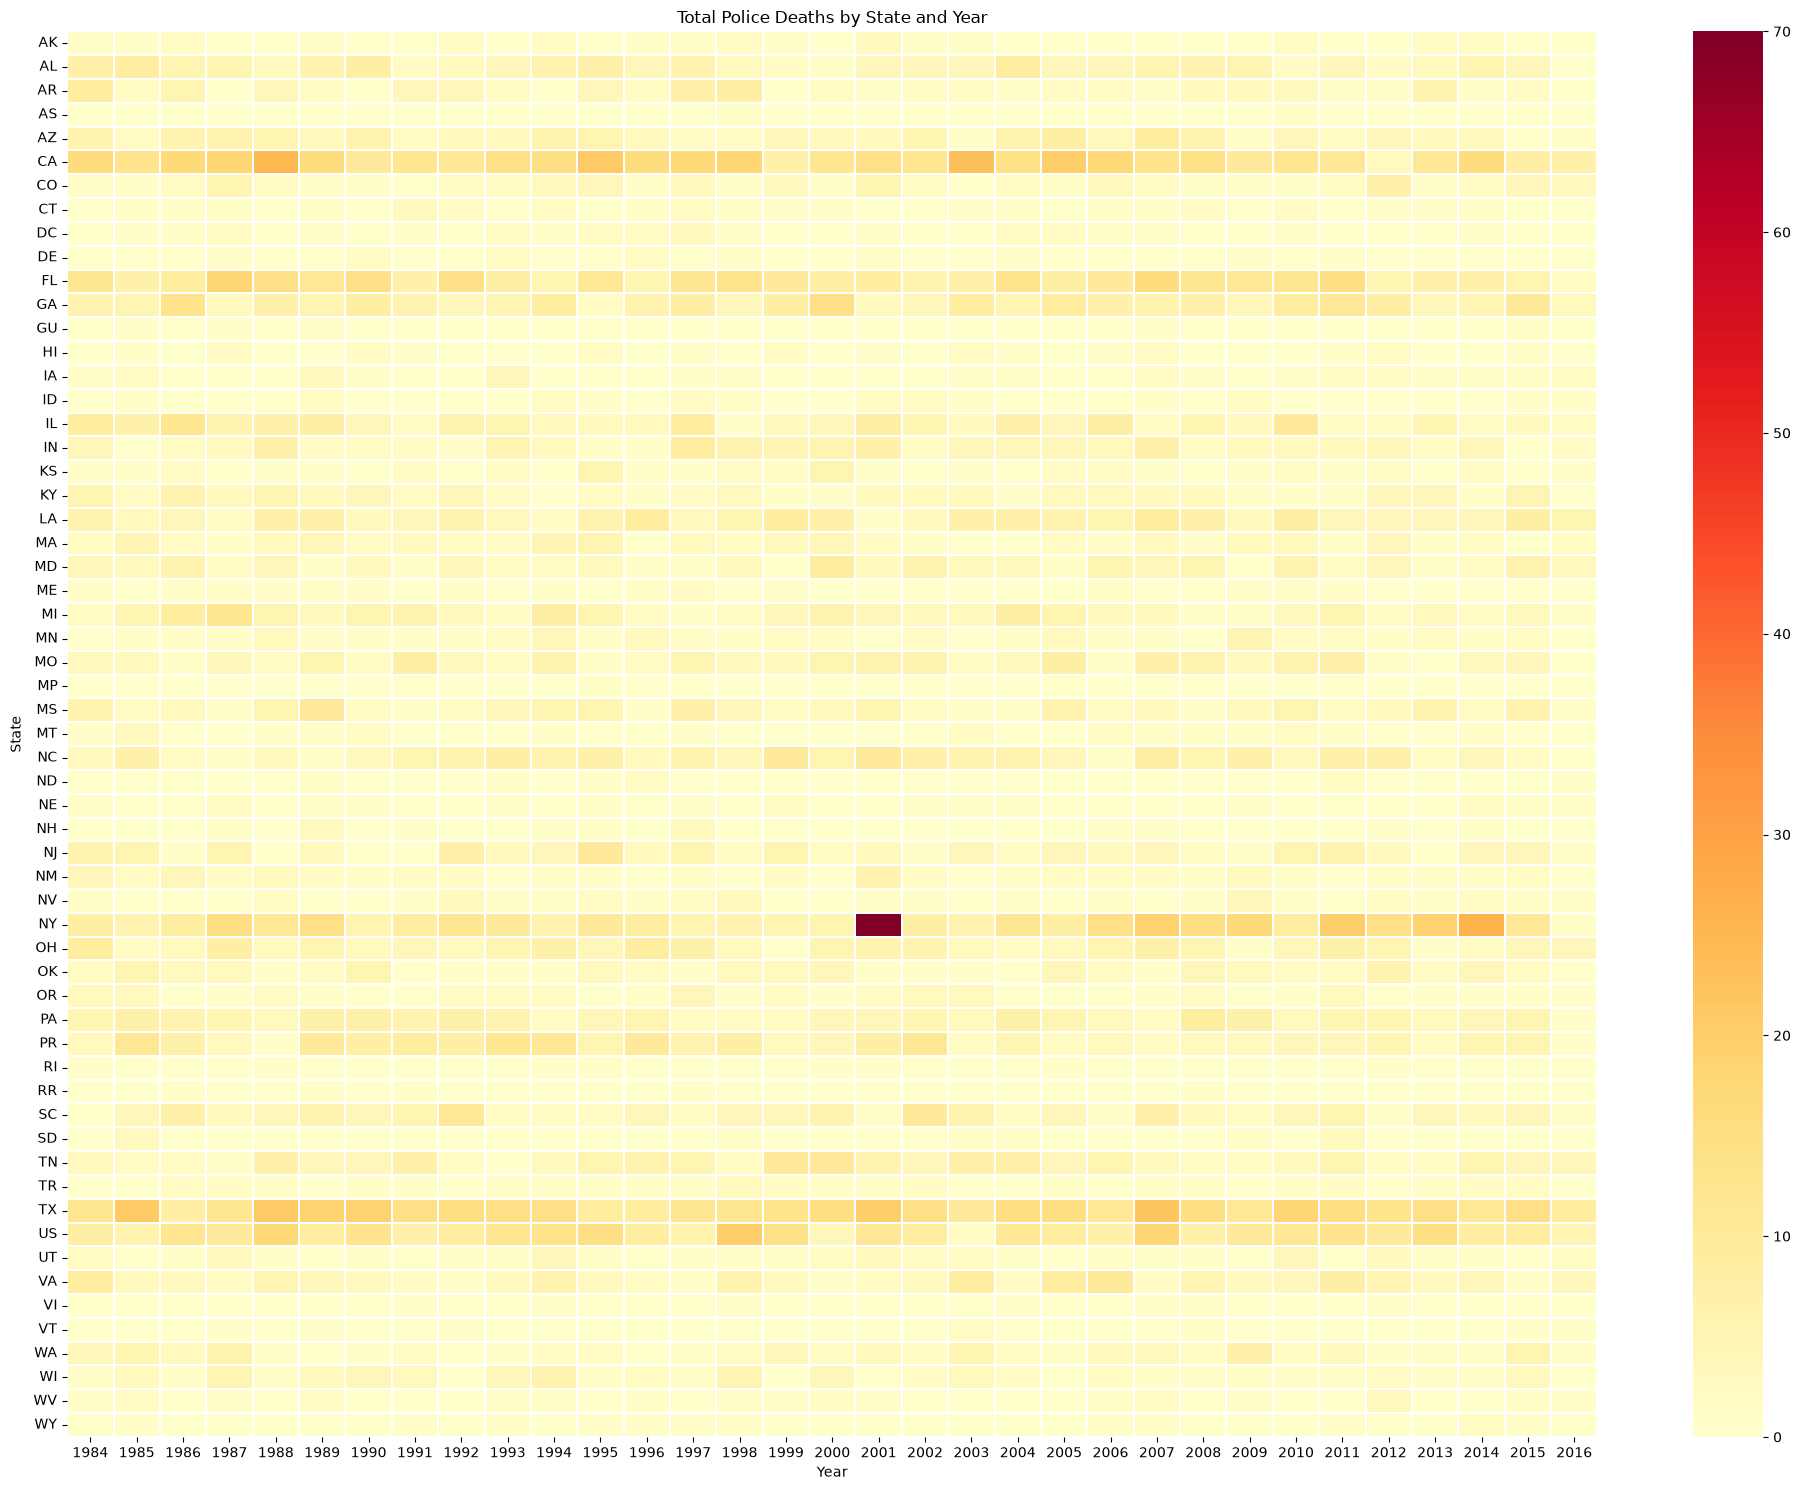

In [13]:
#8. Heatmap of total deaths per state per year

#Answer:
state_year_table = pd.crosstab(
    df_1984_2016['state'],
    df_1984_2016['year']
)

plt.figure(figsize=(20, 15))

sns.heatmap(
    state_year_table,
    cmap='YlOrRd',
    linewidths=0.2
)

plt.title('Total Police Deaths by State and Year')
plt.xlabel('Year')
plt.ylabel('State')
plt.tight_layout()
plt.show()

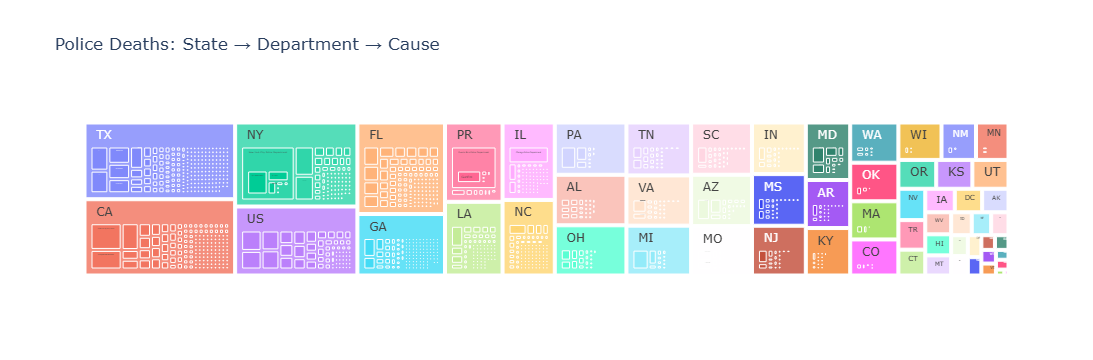

In [14]:
#9. Tree map with three levels: State → City/Description → Cause

#Answer:
treemap_data = (
    df_1984_2016
    .groupby(['state', 'dept_name', 'cause_short'])
    .size()
    .reset_index(name='deaths')
)

fig = px.treemap(
    treemap_data,
    path=['state', 'dept_name', 'cause_short'],
    values='deaths',
    title='Police Deaths: State → Department → Cause'
)

fig.show()

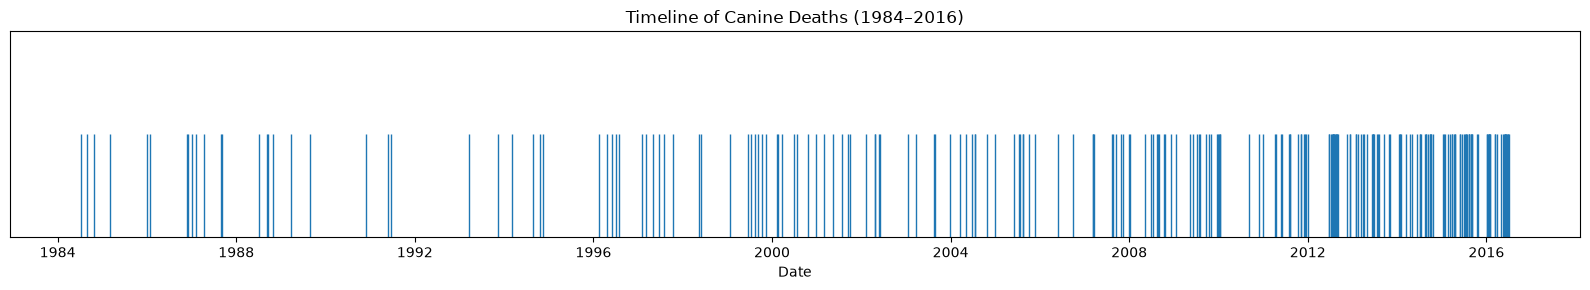

In [15]:
#10. Rug plot showing a timeline of canine deaths

#Answer:
canine_deaths = df_1984_2016[
    df_1984_2016['canine'] == True
].copy()

plt.figure(figsize=(16, 3))

sns.rugplot(
    data=canine_deaths,
    x='date',
    height=0.5
)

plt.title('Timeline of Canine Deaths (1984–2016)')
plt.xlabel('Date')
plt.yticks([])
plt.tight_layout()
plt.show()